# Exploratory Data Analysis 

### Imports 

In [1]:
import sys
from pathlib import Path
# Ensure project root is on sys.path so `import src` works when notebook is run from `notebooks/`
proj_root = Path.cwd().resolve().parent
proj_root_str = str(proj_root)
if proj_root_str not in sys.path:
    sys.path.insert(0, proj_root_str)
print('Added to sys.path:', proj_root_str)

Added to sys.path: /home/melki/Desktop/New Folder/credit-risk-model


In [2]:
from src.data_loader import load_data

from src.preprocessing import (
    df_summary,
    validate_datatypes,
    analyze_distribution,
    get_categorical_cols,
    get_numerical_cols,
    plot_numerical_distributions,
    plot_numerical_boxplots,
    plot_categorical_distributions,
    correlation_analysis,
    outlier_detection_boxplot,
    handle_missing_values,
    save_preprocessed_data
)

In [3]:
# Load the data
df = load_data(file_path="../data/raw/data.csv")
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,False
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,False
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,False
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,False
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,False


In [4]:
validate_datatypes(df)

,Column,Actual Type,Expected Type,Status
0,TransactionId,str,str,✅ Correct
1,BatchId,str,str,✅ Correct
2,AccountId,str,str,✅ Correct
3,SubscriptionId,str,str,✅ Correct
4,CustomerId,str,str,✅ Correct
5,CurrencyCode,category,category,✅ Correct
6,CountryCode,category,category,✅ Correct
7,ProviderId,category,category,✅ Correct
8,ProductId,category,category,✅ Correct
9,ProductCategory,category,category,✅ Correct


### **Overview of the Data**

In [5]:
df_summary(df)

--- DATASET OVERVIEW ---
Dimensions: 95662 rows, 16 columns

--- Column Data Types ---
TransactionId                           str
BatchId                                 str
AccountId                               str
SubscriptionId                          str
CustomerId                              str
CurrencyCode                       category
CountryCode                        category
ProviderId                         category
ProductId                          category
ProductCategory                    category
ChannelId                          category
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[us, UTC]
PricingStrategy                    category
FraudResult                            bool
dtype: object

--- Column Information ---
<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  -

### **Summary Statistics**

In [6]:
analyze_distribution(df)

--- DISTRIBUTION ANALYSIS ---


,Amount,Value
Mean,6.717846e+03,9.900584e+03
Median,1.000000e+03,1.000000e+03
Mode,1.000000e+03,1.000000e+03
Std Dev,1.233068e+05,1.231221e+05
Variance,1.520457e+10,1.515905e+10
Range,1.088000e+07,9.879998e+06
IQR,2.850000e+03,4.725000e+03
Skewness,5.109849e+01,5.129109e+01
Kurtosis,3.363128e+03,3.378069e+03


### **Distribution of Numerical Features**

In [7]:
categorical_cols = get_categorical_cols(df)
numerical_cols = get_numerical_cols(df)

In [8]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,False
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,False
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,False
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,False
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,False


/home/melki/Desktop/New Folder/credit-risk-model/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


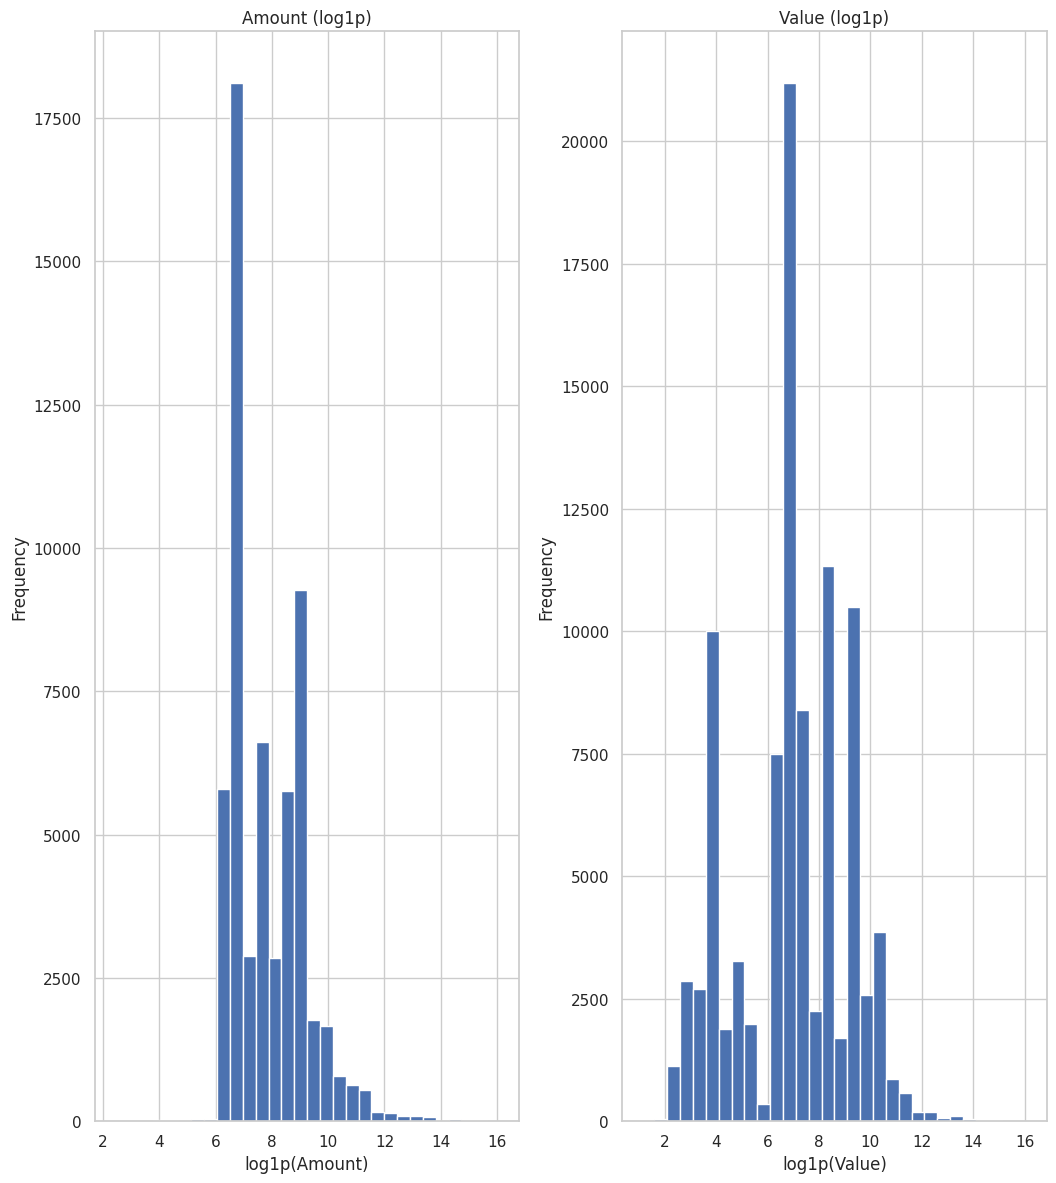

In [9]:
plot_numerical_distributions(df, numerical_cols=numerical_cols, figsize=(16, 12), bins=30, apply_log=True)

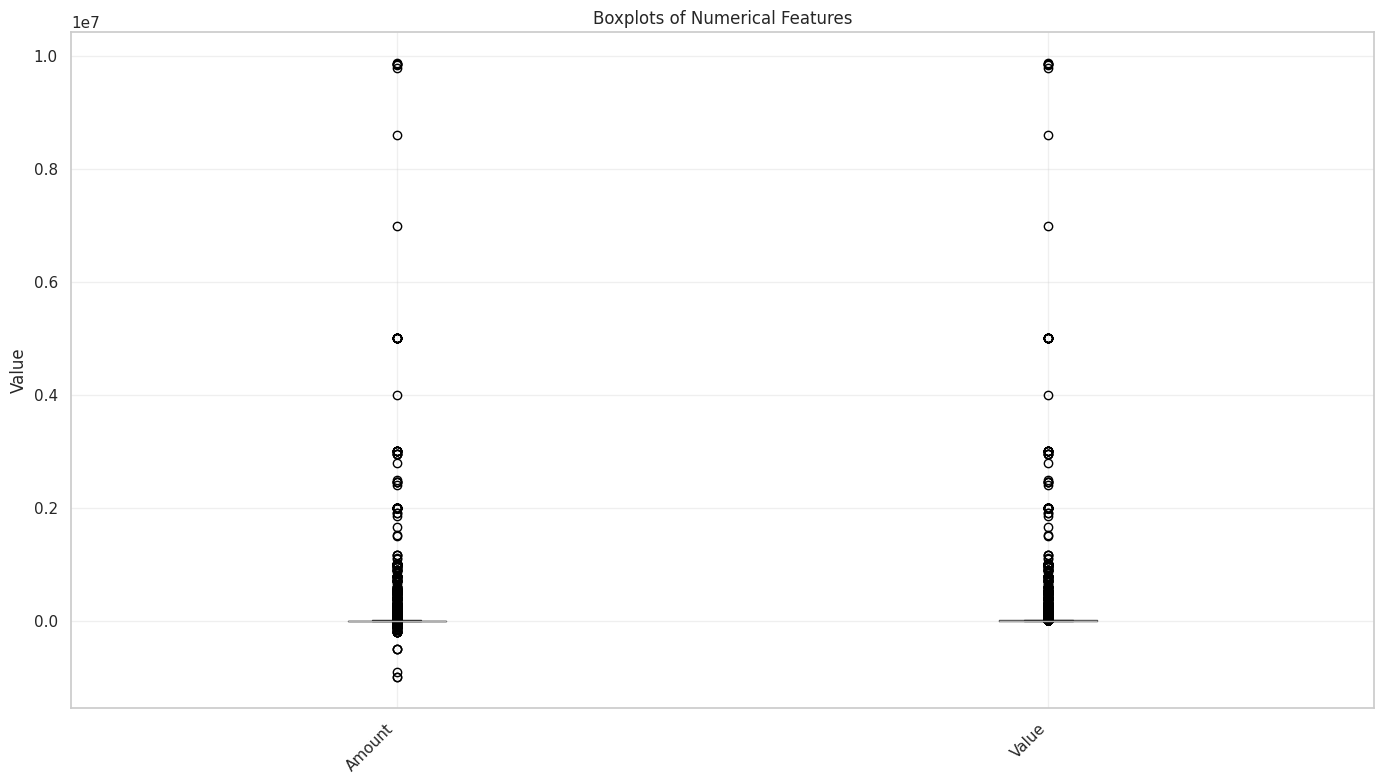

In [10]:
plot_numerical_boxplots(df, numerical_cols=numerical_cols, figsize=(14, 8))

### **Distribution of Categorical Features**

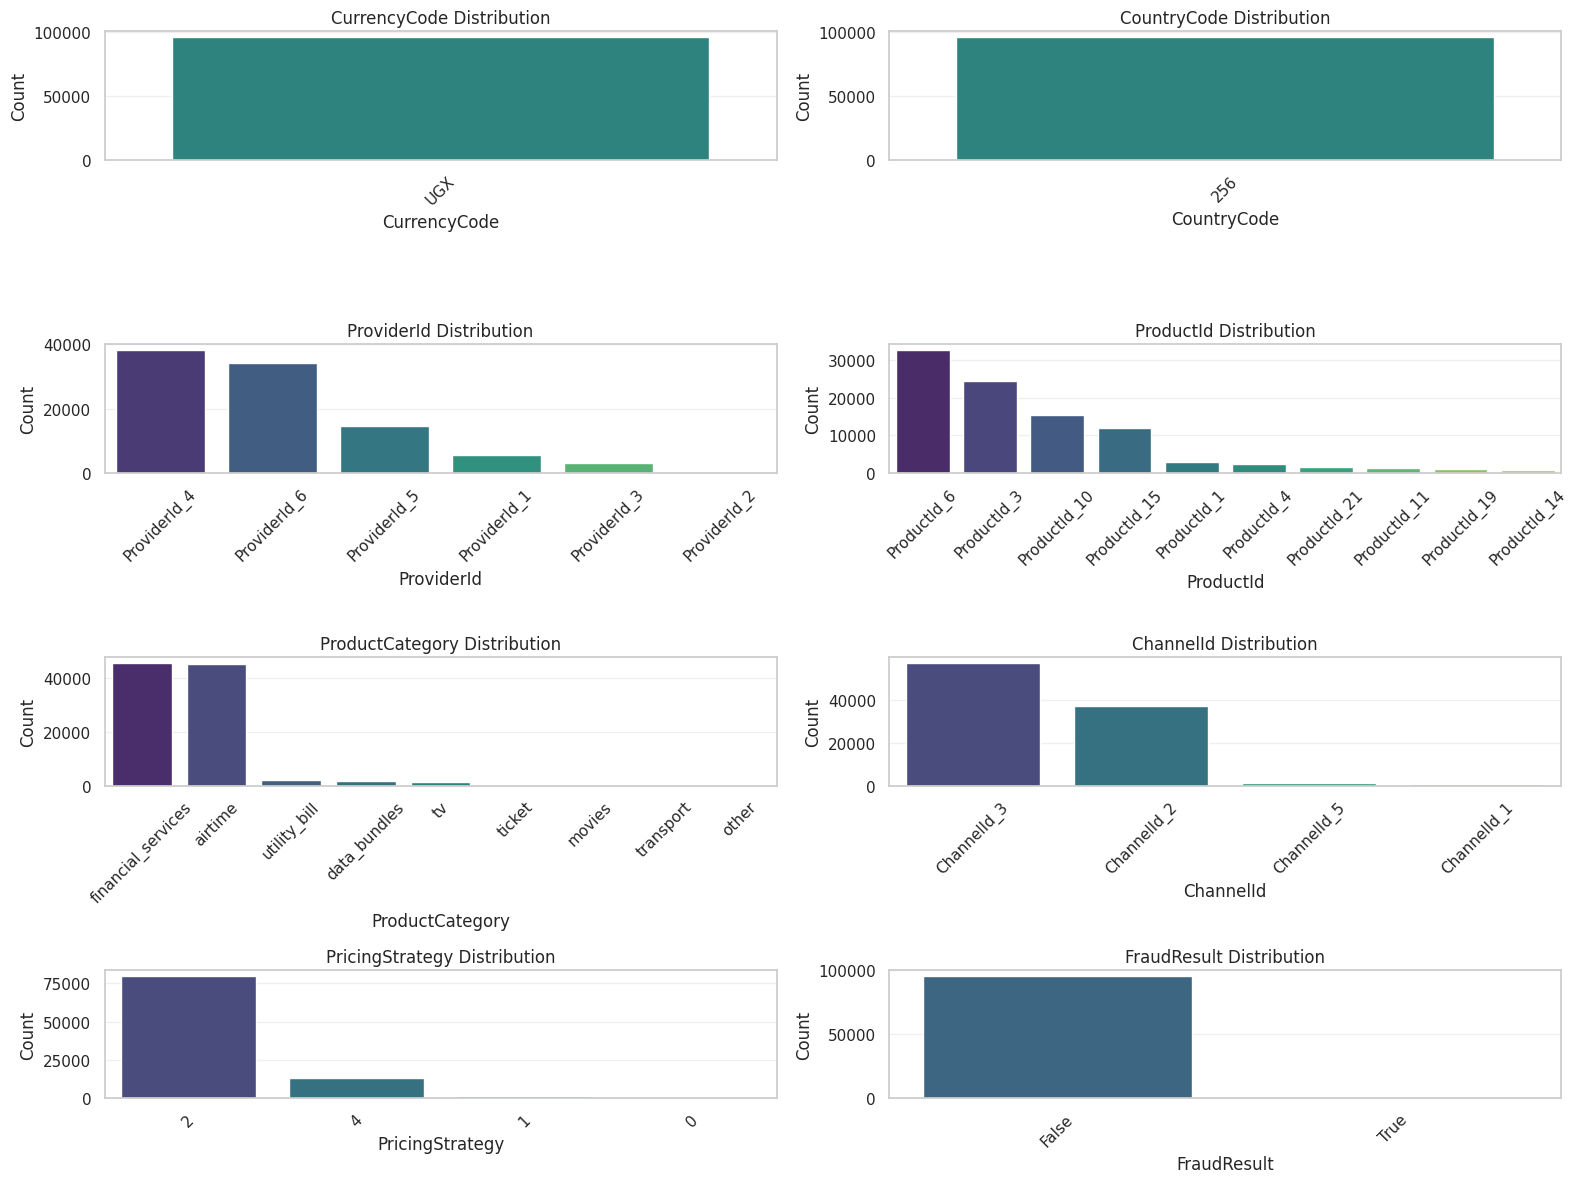

In [11]:
plot_categorical_distributions(df, categorical_cols=categorical_cols, figsize=(16, 12), max_categories=10)

### **Correlation Analysis**

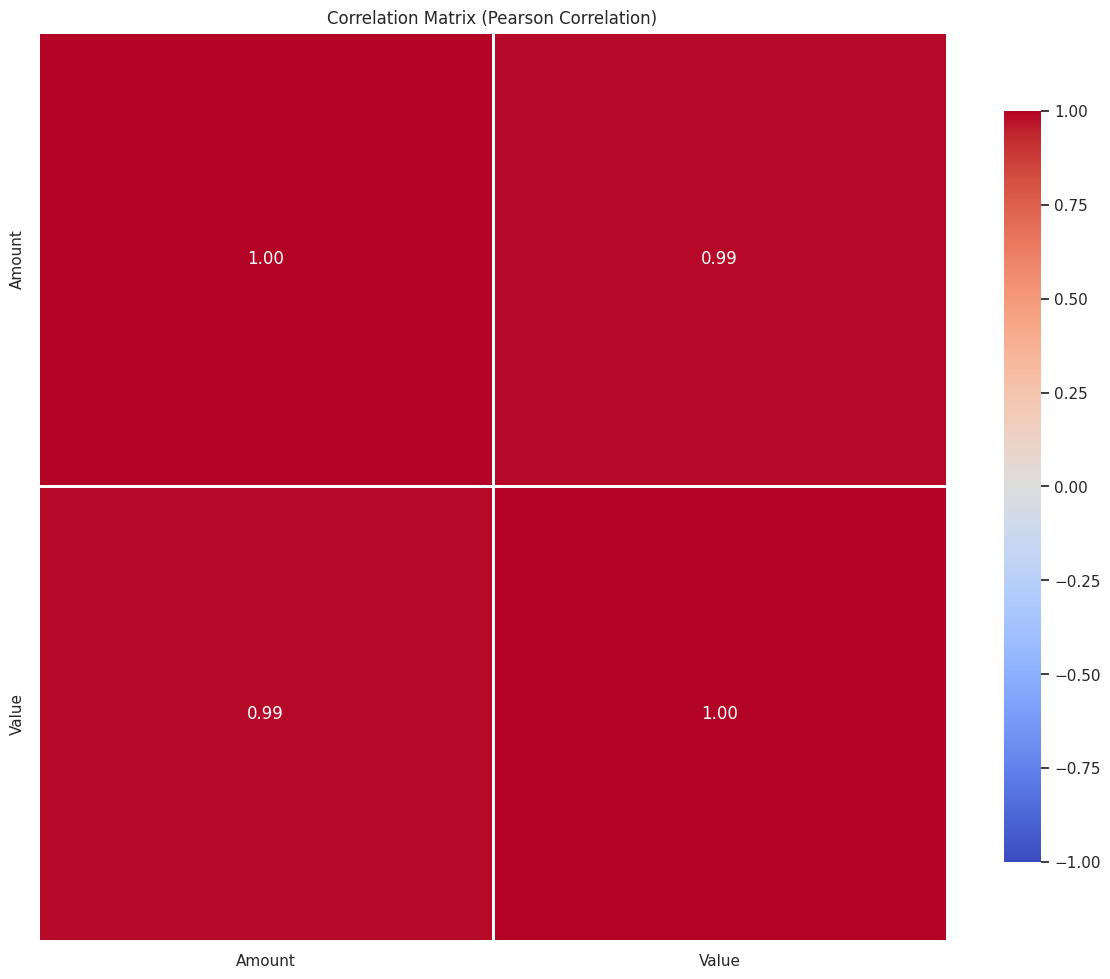

,Amount,Value
Amount,1.000000,0.989692
Value,0.989692,1.000000


In [12]:
correlation_analysis(df, numerical_cols=numerical_cols, figsize=(12, 10))

### **Identifying Missing Values**

In [13]:
handle_missing_values(df)

No missing values detected in the DataFrame.


(              TransactionId         BatchId       AccountId  \
 0       TransactionId_76871   BatchId_36123  AccountId_3957   
 1       TransactionId_73770   BatchId_15642  AccountId_4841   
 2       TransactionId_26203   BatchId_53941  AccountId_4229   
 3         TransactionId_380  BatchId_102363   AccountId_648   
 4       TransactionId_28195   BatchId_38780  AccountId_4841   
 ...                     ...             ...             ...   
 95657   TransactionId_89881   BatchId_96668  AccountId_4841   
 95658   TransactionId_91597    BatchId_3503  AccountId_3439   
 95659   TransactionId_82501  BatchId_118602  AccountId_4841   
 95660  TransactionId_136354   BatchId_70924  AccountId_1346   
 95661   TransactionId_35670   BatchId_29317  AccountId_4841   
 
             SubscriptionId       CustomerId CurrencyCode CountryCode  \
 0       SubscriptionId_887  CustomerId_4406          UGX         256   
 1      SubscriptionId_3829  CustomerId_4406          UGX         256   
 2       Su

### **save preprocessed data**

In [14]:
save_preprocessed_data(df, filename="../data/processed/processed_data.csv")

✅ Preprocessed data saved to ../data/processed/processed_data.csv


### **Outlier Detection**

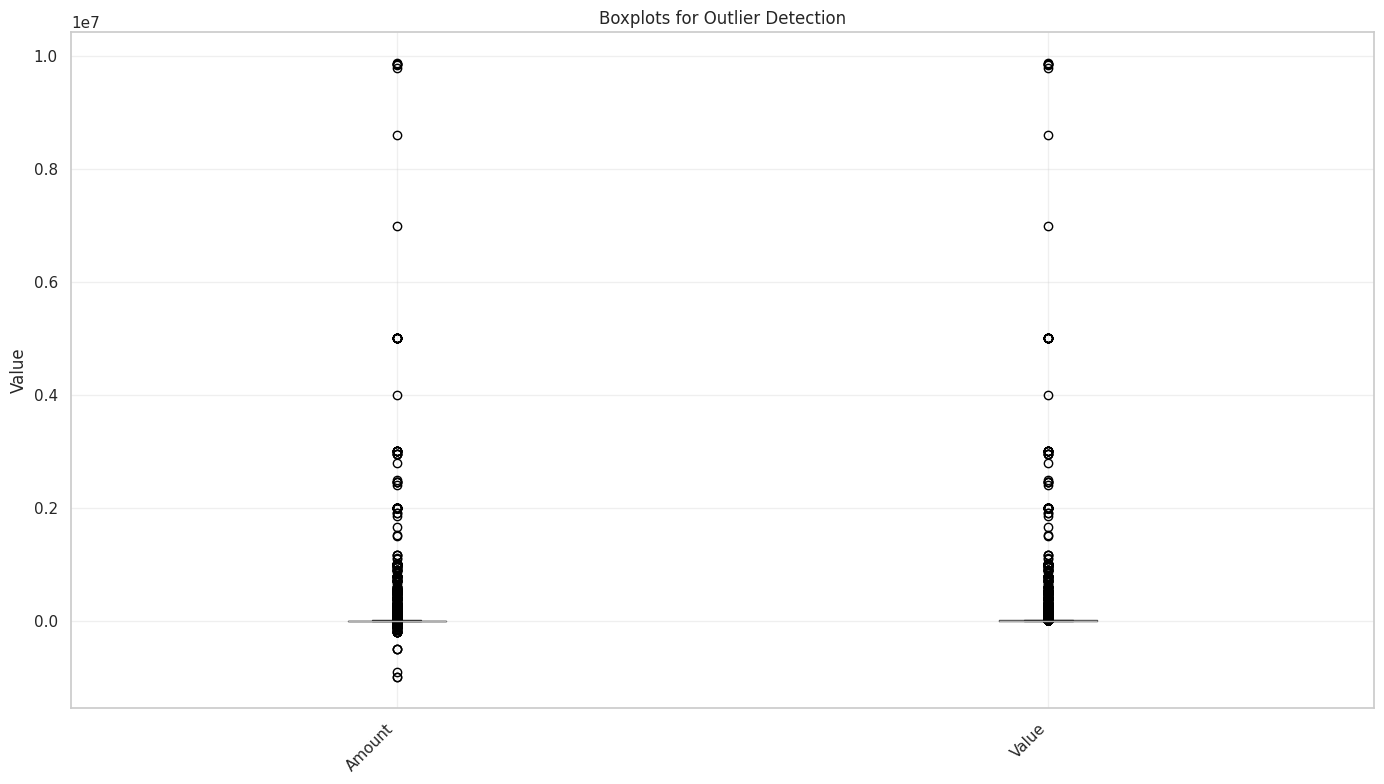

,column,outlier_count,outlier_percent,lower_bound,upper_bound
0,Amount,24441,25.549330,-4325.0,7075.0
1,Value,9021,9.430077,-6812.5,12087.5


In [15]:
outlier_detection_boxplot(df, figsize=(14, 8))

## **Exploratory Data Analysis Summary**

This EDA was performed on a financial transaction dataset (`data.csv`) containing **95,662** records and **16 columns**. The data captures mobile money transactions in Uganda, with features including transaction metadata (`TransactionId`, `BatchId`, `AccountId`, etc.), monetary values (`Amount`, `Value`), categorical attributes (`ProductCategory`, `ChannelId`, `ProviderId`), timestamp (`TransactionStartTime`), and the binary target `FraudResult`.

### Key Steps Performed:
- **Data Loading & Validation**: Confirmed correct data types and structure.
- **Summary Statistics**: No missing values. `Amount` and `Value` show extreme skewness (~51) and kurtosis (>3300), indicating heavy-tailed distributions with many large and negative values.
- **Distribution Analysis**: Strong positive skew and high outlier presence in monetary features.
- **Missing Value Handling**: There were no missing values found in the dataset
- **Outlier Detection**: Boxplot analysis revealed **25.55%** outliers in `Amount` and **9.43%** in `Value`.
- **Preprocessing**: Data was cleaned and saved to `processed_data.csv`.

### Top 5 Most Important Insights:

1. **Highly Imbalanced Target**: `FraudResult` is extremely rare (typical in fraud detection), meaning any modeling effort will require strong class imbalance handling (e.g., SMOTE, weighted loss, or anomaly detection techniques).

2. **Extreme Skew in Monetary Features**: Both `Amount` and `Value` are heavily right-skewed with massive outliers. This suggests the presence of high-value transactions and potential refunds/chargebacks (negative `Amount`). Log transformation or robust scaling will be essential.

3. **High Outlier Prevalence**: Over 25% of `Amount` values are statistical outliers. These are likely legitimate business cases (e.g., large utility or merchant payments) rather than noise, so careful treatment (capping, segmentation, or tree-based models) is recommended.

4. **Categorical Diversity**: Many high-cardinality ID columns (`AccountId`, `CustomerId`, etc.) and meaningful categories (`ProductCategory`, `ChannelId`). These are strong candidates for target encoding or embedding, especially for fraud pattern detection.

5. **Temporal Aspect**: `TransactionStartTime` provides rich time-based features (hour, day of week, etc.) that should be engineered, as fraud often exhibits temporal patterns (e.g., unusual hours or bursts).

**Recommendation**: Focus modeling on robust, non-parametric algorithms (e.g., XGBoost, LightGBM) or hybrid approaches combining engineered features with anomaly detection, given the extreme imbalance and outlier characteristics.